In [1]:
import sys
sys.path.append("E:\\wikiart_project")

from config import (
    set_seed, get_split_indices, get_transforms,
    WikiArtDataset, NUM_STYLES, NUM_GENRES, SAVE_DIR
)

import os
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models
from datasets import load_dataset
from tqdm import tqdm
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, top_k_accuracy_score
)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Load dataset ────────────────────────────────────────
print("Loading dataset...")
dataset = load_dataset("huggan/wikiart", split="train")
splits = get_split_indices(len(dataset))
print(f"Test set size: {len(splits['test'])}")

# ── Get class names ─────────────────────────────────────
style_names = dataset.features['style'].names
genre_names = dataset.features['genre'].names

# ── Test set DataLoader (image_size=224 works for all 3) ─
_, eval_transform = get_transforms(224)
test_dataset = WikiArtDataset(dataset, splits['test'], eval_transform)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)
print("Test DataLoader ready!")

# ── Define all 3 model architectures ────────────────────
class MultiTaskResNet(nn.Module):
    def __init__(self, num_styles=NUM_STYLES, num_genres=NUM_GENRES):
        super().__init__()
        backbone = models.resnet50(weights=None)
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])
        self.style_head = nn.Linear(2048, num_styles)
        self.genre_head = nn.Linear(2048, num_genres)
    def forward(self, x):
        f = self.backbone(x).flatten(1)
        return self.style_head(f), self.genre_head(f)

class MultiTaskEfficientNet(nn.Module):
    def __init__(self, num_styles=NUM_STYLES, num_genres=NUM_GENRES):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b4', pretrained=False, num_classes=0)
        nf = self.backbone.num_features
        self.style_head = nn.Linear(nf, num_styles)
        self.genre_head = nn.Linear(nf, num_genres)
    def forward(self, x):
        f = self.backbone(x)
        return self.style_head(f), self.genre_head(f)

class MultiTaskViT(nn.Module):
    def __init__(self, num_styles=NUM_STYLES, num_genres=NUM_GENRES):
        super().__init__()
        self.backbone = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=0)
        nf = self.backbone.num_features
        self.style_head = nn.Linear(nf, num_styles)
        self.genre_head = nn.Linear(nf, num_genres)
    def forward(self, x):
        f = self.backbone(x)
        return self.style_head(f), self.genre_head(f)

print("Model classes defined!")

Using device: cuda
Loading dataset...


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/45 [00:00<?, ?it/s]

Test set size: 12217
Test DataLoader ready!
Model classes defined!


In [2]:
def evaluate_model(model, model_name, test_loader, device):
    """Run model on test set and collect predictions."""
    model.eval()
    all_style_preds, all_style_top5, all_style_true = [], [], []
    all_genre_preds, all_genre_true = [], []

    with torch.no_grad():
        for images, styles, genres in tqdm(test_loader, desc=f"Evaluating {model_name}"):
            images = images.to(device)
            style_out, genre_out = model(images)

            # Top-1 predictions
            style_pred = style_out.argmax(1).cpu().numpy()
            genre_pred = genre_out.argmax(1).cpu().numpy()

            # Top-5 predictions for style
            style_top5 = style_out.topk(5, dim=1).indices.cpu().numpy()

            all_style_preds.extend(style_pred)
            all_style_top5.append(style_out.cpu().numpy())  # save logits for top-k
            all_style_true.extend(styles.numpy())
            all_genre_preds.extend(genre_pred)
            all_genre_true.extend(genres.numpy())

    style_top5_logits = np.concatenate(all_style_top5, axis=0)

    return {
        'style_preds': np.array(all_style_preds),
        'style_true':  np.array(all_style_true),
        'style_logits': style_top5_logits,
        'genre_preds': np.array(all_genre_preds),
        'genre_true':  np.array(all_genre_true),
    }

# ── Load and evaluate all 3 models ──────────────────────
results = {}

# 1. ResNet-50
print("\n" + "="*60)
print("Loading ResNet-50...")
model = MultiTaskResNet().to(device)
model.load_state_dict(torch.load(f"{SAVE_DIR}\\resnet50_wikiart.pth"))
results['ResNet-50'] = evaluate_model(model, 'ResNet-50', test_loader, device)
del model
torch.cuda.empty_cache()

# 2. EfficientNet-B4
print("\n" + "="*60)
print("Loading EfficientNet-B4...")
model = MultiTaskEfficientNet().to(device)
model.load_state_dict(torch.load(f"{SAVE_DIR}\\efficientnet_b4_wikiart.pth"))
results['EfficientNet-B4'] = evaluate_model(model, 'EfficientNet-B4', test_loader, device)
del model
torch.cuda.empty_cache()

# 3. ViT-B/16
print("\n" + "="*60)
print("Loading ViT-B/16...")
model = MultiTaskViT().to(device)
model.load_state_dict(torch.load(f"{SAVE_DIR}\\vit_base_patch16_224_wikiart.pth"))
results['ViT-B/16'] = evaluate_model(model, 'ViT-B/16', test_loader, device)
del model
torch.cuda.empty_cache()

print("\nAll models evaluated!")


Loading ResNet-50...


C:\Users\yimin\AppData\Local\Temp\ipykernel_25132\1247254292.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{SAVE_DIR}\\resnet50_wik


Loading EfficientNet-B4...


C:\Users\yimin\AppData\Local\Temp\ipykernel_25132\1247254292.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{SAVE_DIR}\\efficientnet


Loading ViT-B/16...


C:\Users\yimin\AppData\Local\Temp\ipykernel_25132\1247254292.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{SAVE_DIR}\\vit_base_pat


All models evaluated!



FINAL TEST SET RESULTS
          Model Style Top-1 Style Top-5 Style Macro-F1 Genre Top-1 Genre Macro-F1
      ResNet-50      0.5913      0.9389         0.5601      0.6776         0.6640
EfficientNet-B4      0.6030      0.9437         0.5888      0.6785         0.6603
       ViT-B/16      0.5760      0.9271         0.5297      0.6587         0.6503

Saved to: E:\wikiart_project\test_metrics.csv


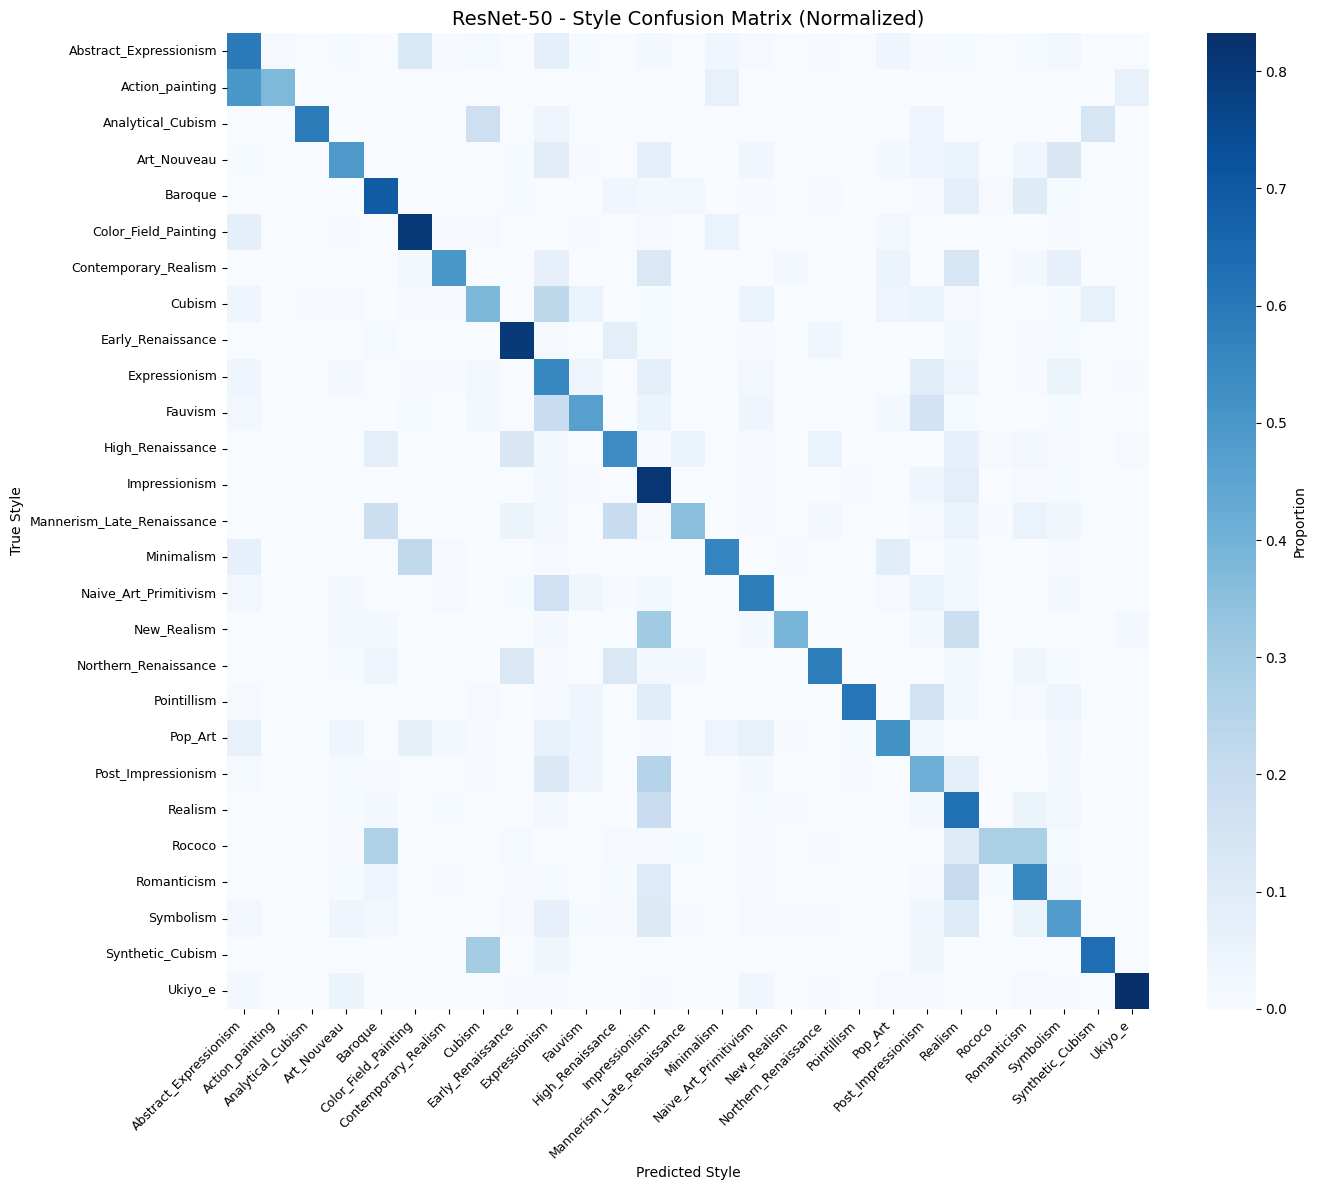

Saved: resnet_50_confusion_matrix.png


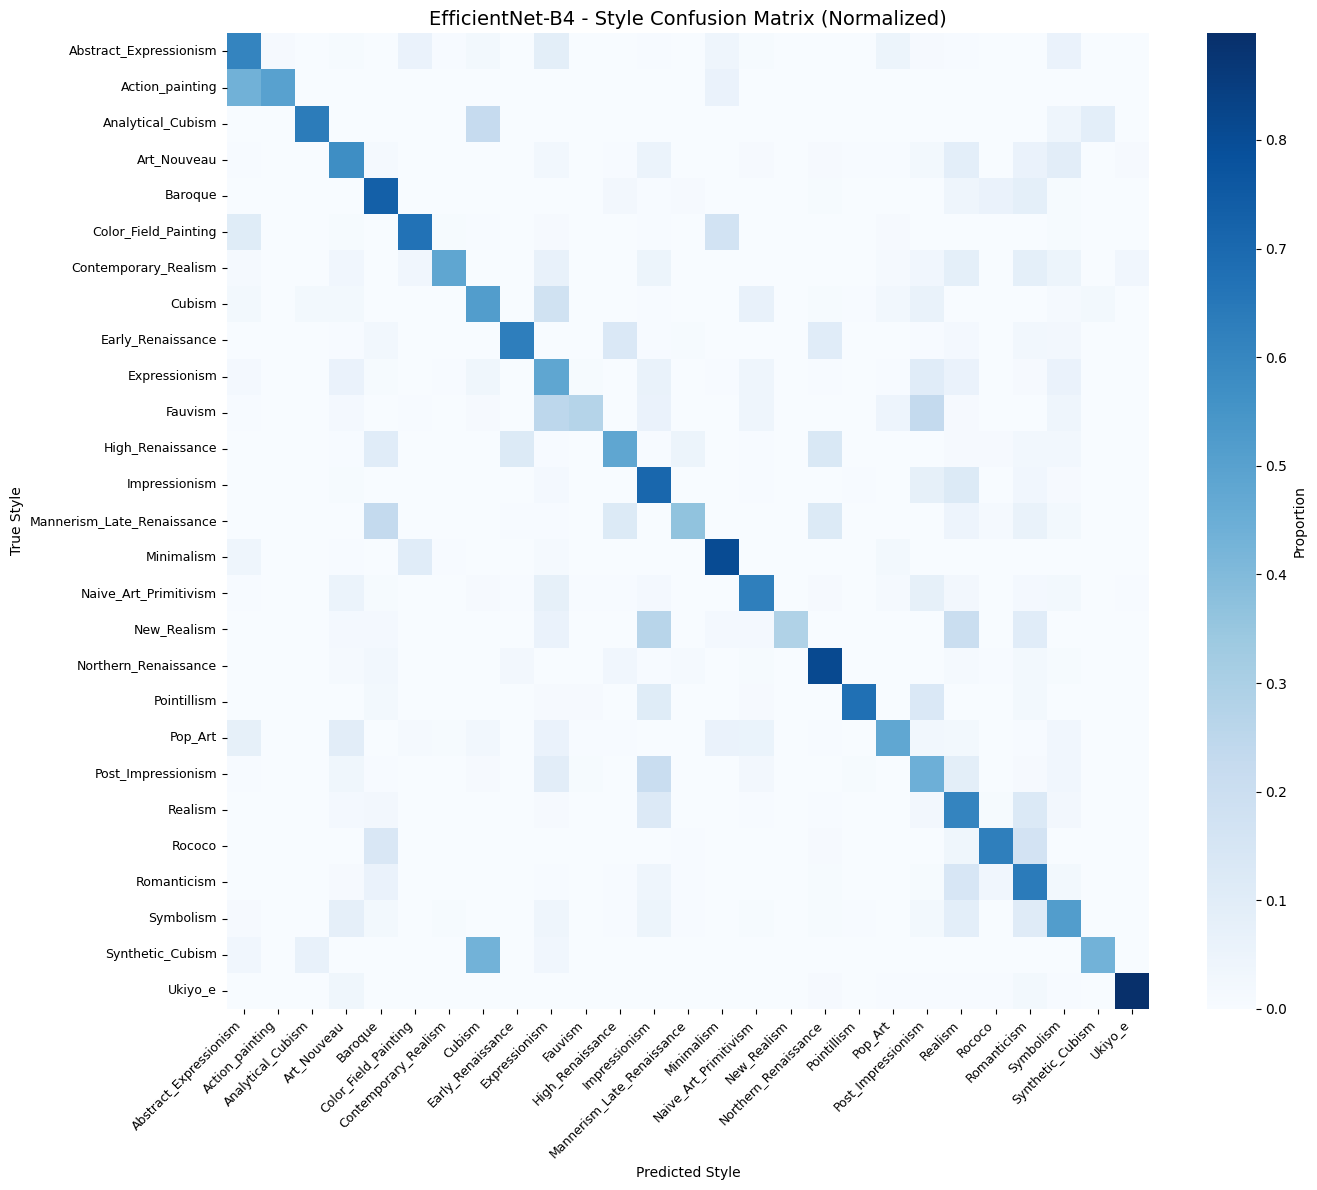

Saved: efficientnet_b4_confusion_matrix.png


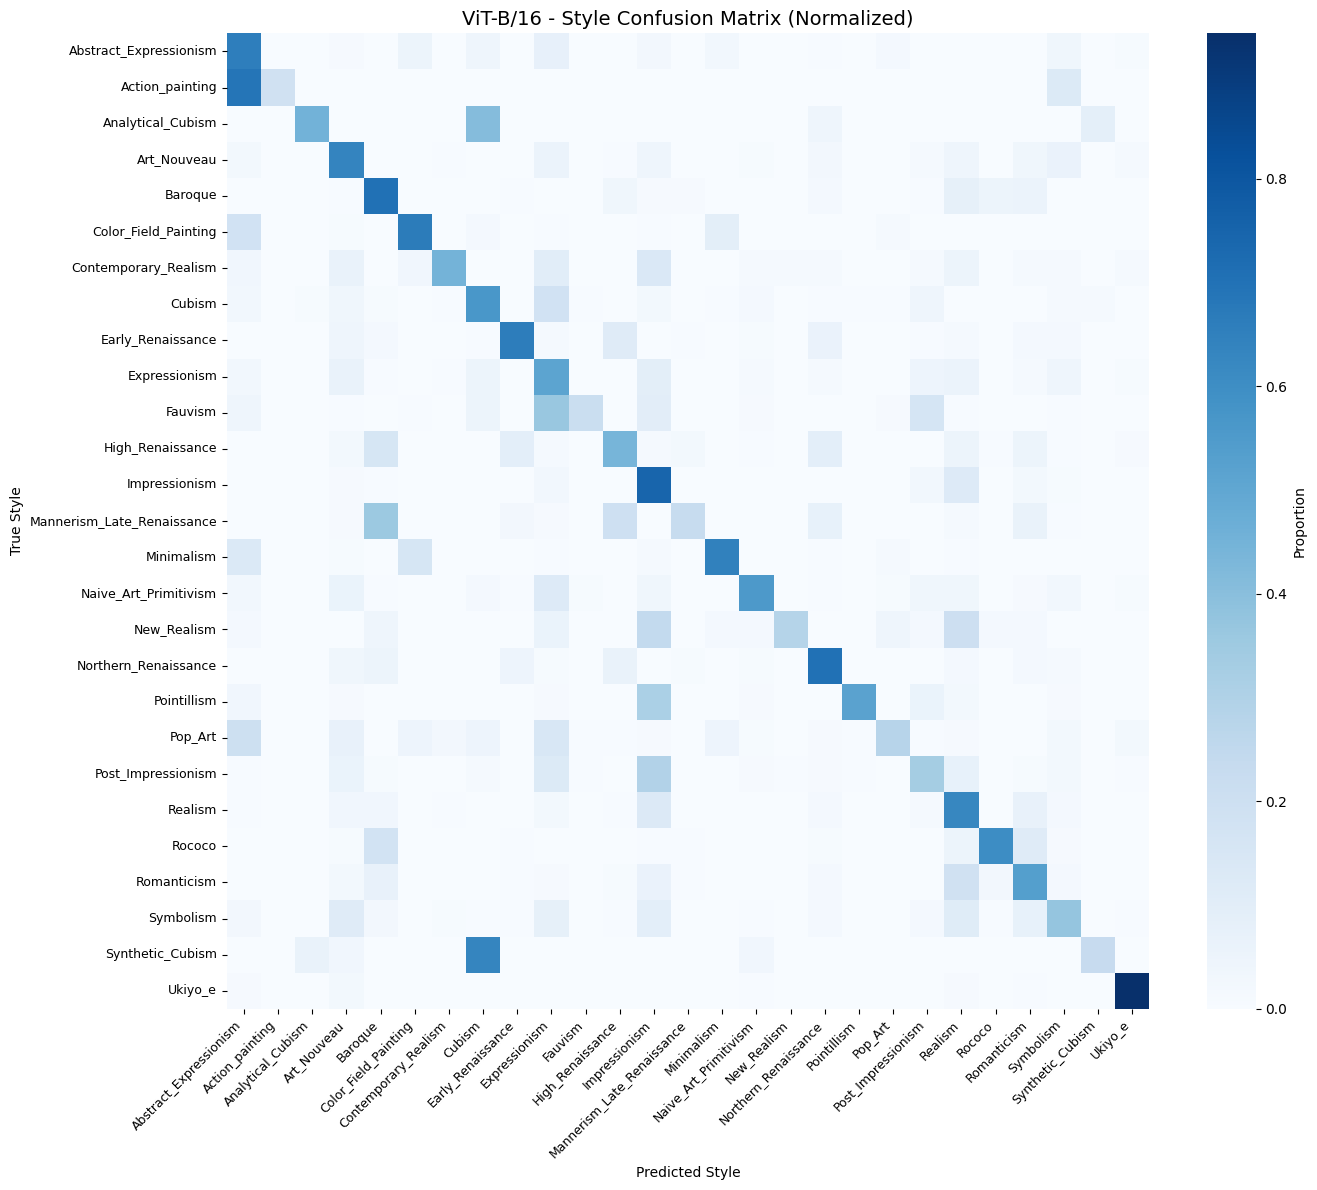

Saved: vit_b_16_confusion_matrix.png

All metrics and confusion matrices generated!


In [3]:
import pandas as pd

# ── Compute metrics for each model ──────────────────────
metrics_table = []

for model_name, res in results.items():
    style_top1 = accuracy_score(res['style_true'], res['style_preds'])
    style_top5 = top_k_accuracy_score(res['style_true'], res['style_logits'], k=5)
    style_f1   = f1_score(res['style_true'], res['style_preds'], average='macro')

    genre_top1 = accuracy_score(res['genre_true'], res['genre_preds'])
    genre_f1   = f1_score(res['genre_true'], res['genre_preds'], average='macro')

    metrics_table.append({
        'Model': model_name,
        'Style Top-1': f"{style_top1:.4f}",
        'Style Top-5': f"{style_top5:.4f}",
        'Style Macro-F1': f"{style_f1:.4f}",
        'Genre Top-1': f"{genre_top1:.4f}",
        'Genre Macro-F1': f"{genre_f1:.4f}",
    })

# ── Display as a nice table ─────────────────────────────
df = pd.DataFrame(metrics_table)
print("\n" + "="*80)
print("FINAL TEST SET RESULTS")
print("="*80)
print(df.to_string(index=False))
df.to_csv(f"{SAVE_DIR}\\test_metrics.csv", index=False)
print(f"\nSaved to: {SAVE_DIR}\\test_metrics.csv")

# ── Plot confusion matrix for each model (style only) ───
for model_name, res in results.items():
    cm = confusion_matrix(res['style_true'], res['style_preds'])
    # Normalize per row (so each row sums to 1)
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(14, 12))
    sns.heatmap(cm_normalized, annot=False, cmap='Blues',
                xticklabels=style_names, yticklabels=style_names,
                cbar_kws={'label': 'Proportion'})
    plt.title(f'{model_name} - Style Confusion Matrix (Normalized)', fontsize=14)
    plt.xlabel('Predicted Style')
    plt.ylabel('True Style')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    save_name = model_name.replace('-', '_').replace('/', '_').lower()
    plt.savefig(f'{SAVE_DIR}\\{save_name}_confusion_matrix.png', dpi=150)
    plt.show()
    print(f"Saved: {save_name}_confusion_matrix.png")

print("\nAll metrics and confusion matrices generated!")